# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [15]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [16]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [17]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [18]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [19]:
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [20]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked')

In [21]:
# Combinar con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

In [29]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,sex_label,embarked_C,embarked_Q,embarked_S
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,1,False,False,True
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,0,True,False,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,0,False,False,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,0,False,False,True
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1,False,False,True


In [27]:
data[['sex', 'sex_label']].head()

,sex,sex_label
0,male,1
1,female,0
2,female,0
3,female,0
4,male,1


In [28]:
data.filter(like='embarked').head()

,embarked,embarked_C,embarked_Q,embarked_S
0,S,False,False,True
1,C,True,False,False
2,S,False,False,True
3,S,False,False,True
4,S,False,False,True


LabelEncoder transforma los valores según la categoría en la misma columna reemplazando los valores por 0 y 1. Mientras que OneHotEncoder generó 3 nuevas columnas con valores binarios dependiendo de si embarcaron o no en dicho puerto. De esta forma, se preserva la naturaleza categórica de los datos sin imponer una relación de orden entre ellos, porque cada categoría es independiente.

### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

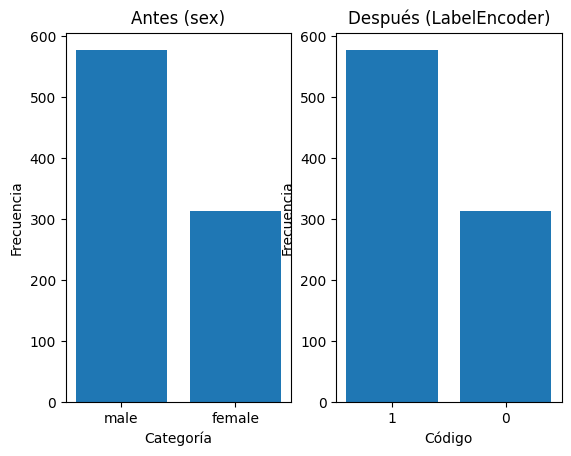

In [31]:
# Frecuencias antes (texto)
freq_original = data['sex'].value_counts()

# Frecuencias después (LabelEncoder)
freq_encoded = data['sex_label'].value_counts()

# Crear figura
fig, axs = plt.subplots(1, 2)

# Antes
axs[0].bar(freq_original.index, freq_original.values)
axs[0].set_title('Antes (sex)')
axs[0].set_xlabel('Categoría')
axs[0].set_ylabel('Frecuencia')

# Después
axs[1].bar(freq_encoded.index.astype(str), freq_encoded.values)
axs[1].set_title('Después (LabelEncoder)')
axs[1].set_xlabel('Código')
axs[1].set_ylabel('Frecuencia')

plt.show()

### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

In [32]:
class_dummies = pd.get_dummies(data['class'], prefix='class')

data = pd.concat([data, class_dummies], axis=1)

data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,...,embark_town,alive,alone,sex_label,embarked_C,embarked_Q,embarked_S,class_First,class_Second,class_Third
0,0,3,male,22.0,1,0,7.2500,S,Third,man,...,Southampton,no,False,1,False,False,True,False,False,True
1,1,1,female,38.0,1,0,71.2833,C,First,woman,...,Cherbourg,yes,False,0,True,False,False,True,False,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,...,Southampton,yes,True,0,False,False,True,False,False,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,...,Southampton,yes,False,0,False,False,True,True,False,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,...,Southampton,no,True,1,False,False,True,False,False,True


OneHotEncoder es más adecuado para variables categóricas nominales como 'class', ya que transforma cada categoría en una variable binaria independiente. Esto evita la introducción de relaciones de orden artificial que sí aparecen con LabelEncoder, donde los valores numéricos pueden ser interpretados como magnitudes. De esta forma, OneHotEncoder permite que los modelos de machine learning traten cada categoría de manera independiente, mejorando la representación de los datos.

### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

La elección dependería del modelo. Sin embargo, OneHotEncoder me es preferible, porque mantiene la naturaleza de las categorías aunque, puede caer en la maldición de la dimensionalidad. 

Aún así, sería mi preferido para variables nominales, ya que LabelEncoder puede introducir una jerarquía inexistente a los datos, afectando el comportamiento del modelo. 

En caso de ser variables ordinales, elegiría LabelEncoder, porque sí necesitan la representación de una jerarquía. 

Es importante tener a ambos en consideración dependiendo del tipo de datos a manejar para evitar interpretaciones incorrectas por parte del modelo.